<a href="https://colab.research.google.com/github/ValenteHC/Probabilidad--UNIDAD-1/blob/main/UNIDAD5/Practica_Final_UNIDAD5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBABILIDAD Y ESTADISTICA

##UNIDAD 5: Regresión y Correlación

###FACILITADOR: Jose Gabriel Rodrigues Rivas

#### Alumno: HERRERA CARRERA VALENTIN

##### **PRACTICA FINAL**


ANÁLISIS DE: grupo1.csv

--- Descripción Estadística ---
       HorasEstudio  Calificacion
count     50.000000      50.00000
mean      14.352000      83.78820
std        4.219174       7.83389
min        3.790000      68.46000
25%       12.032500      78.03500
50%       14.600000      84.49000
75%       17.715000      88.09000
max       20.000000     100.00000

--- Resultados del Modelo ---
Ecuación de la recta: Y = -0.1061X + 85.3107
Coeficiente de Correlación (r): -0.0571
Coeficiente de Determinación (R²): 0.0033
Valor p (Significancia): 6.9351e-01


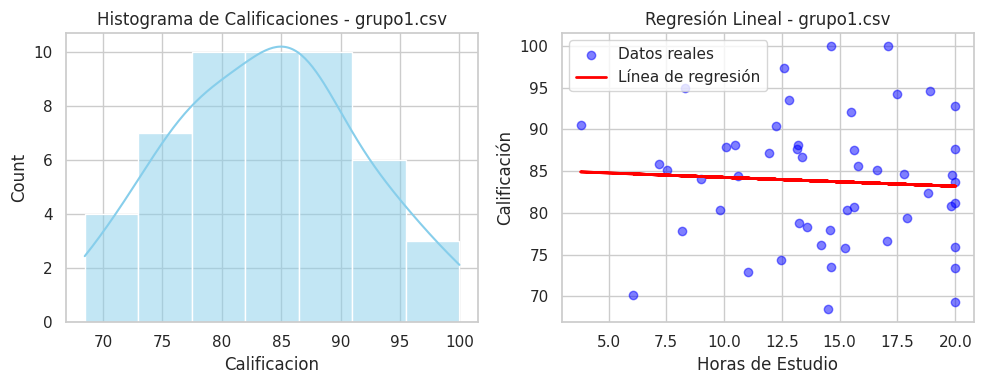


ANÁLISIS DE: grupo2.csv

--- Descripción Estadística ---
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.912000
std        4.219174     20.668922
min        3.790000     26.100000
25%       12.032500     63.500000
50%       14.600000     78.550000
75%       17.715000     93.300000
max       20.000000     99.000000

--- Resultados del Modelo ---
Ecuación de la recta: Y = 4.2227X + 15.3075
Coeficiente de Correlación (r): 0.8620
Coeficiente de Determinación (R²): 0.7430
Valor p (Significancia): 9.0777e-16


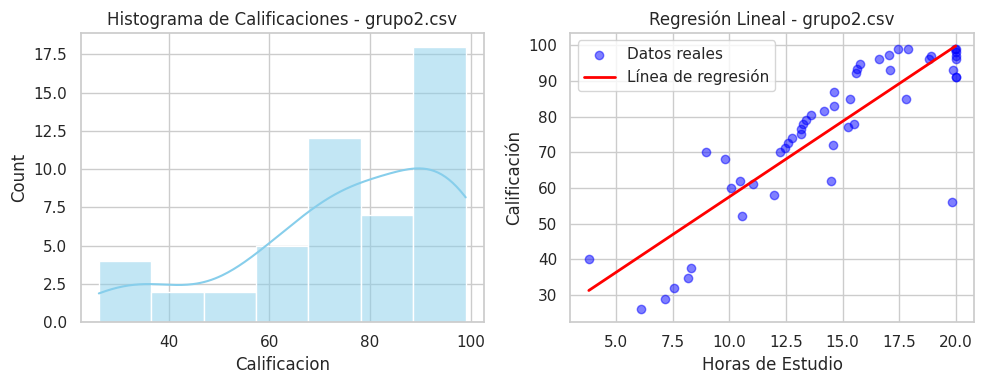


ANÁLISIS DE: grupo3.csv

--- Descripción Estadística ---
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000     99.000000

--- Resultados del Modelo ---
Ecuación de la recta: Y = 5.2857X + 0.1081
Coeficiente de Correlación (r): 0.9422
Coeficiente de Determinación (R²): 0.8878
Valor p (Significancia): 1.9342e-24


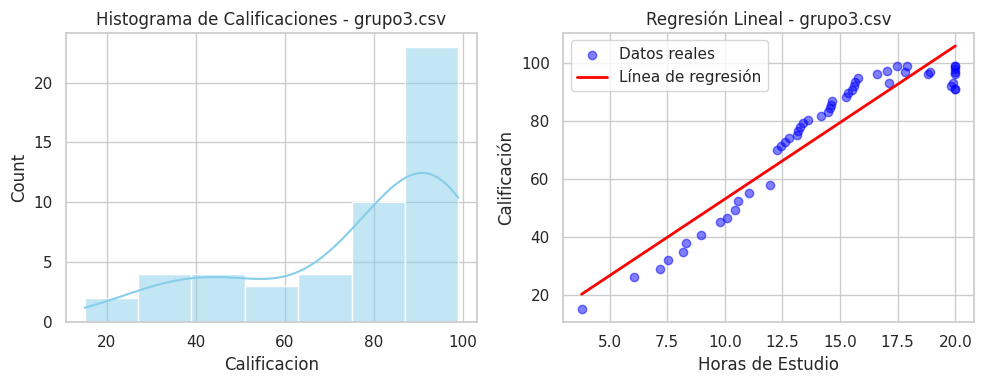

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
sns.set_theme(style="whitegrid")

def analizar_grupo(file_name):
    print(f"\n{'='*40}")
    print(f"ANÁLISIS DE: {file_name}")
    print(f"{'='*40}")
    try:
        df = pd.read_csv(file_name)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {file_name}")
        return

    #Exploración inicial
    print("\n--- Descripción Estadística ---")
    print(df.describe())

    #Histograma de Calificaciones
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df['Calificacion'], kde=True, color='skyblue')
    plt.title(f'Histograma de Calificaciones - {file_name}')

    #Preparación de datos para Regresión
    X = df[['HorasEstudio']].values
    y = df['Calificacion'].values
    model = LinearRegression()
    model.fit(X, y)
    intercepto = model.intercept_
    pendiente = model.coef_[0]
    r_cuadrado = model.score(X, y)

    corr, p_value = pearsonr(df['HorasEstudio'], df['Calificacion'])

    print("\n--- Resultados del Modelo ---")
    print(f"Ecuación de la recta: Y = {pendiente:.4f}X + {intercepto:.4f}")
    print(f"Coeficiente de Correlación (r): {corr:.4f}")
    print(f"Coeficiente de Determinación (R²): {r_cuadrado:.4f}")
    print(f"Valor p (Significancia): {p_value:.4e}")

    #Visualización: Dispersión y Línea de Regresión
    plt.subplot(1, 2, 2)
    plt.scatter(X, y, color='blue', alpha=0.5, label='Datos reales')
    plt.plot(X, model.predict(X), color='red', linewidth=2, label='Línea de regresión')
    plt.xlabel('Horas de Estudio')
    plt.ylabel('Calificación')
    plt.title(f'Regresión Lineal - {file_name}')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "pendiente": pendiente,
        "correlacion": corr,
        "r_cuadrado": r_cuadrado,
        "p_valor": p_value
    }
archivos = ['grupo1.csv', 'grupo2.csv', 'grupo3.csv']
resultados = {}

for archivo in archivos:
    resultados[archivo] = analizar_grupo(archivo)


 RESULTADOS PARA: Grupo 1 (grupo1.csv)


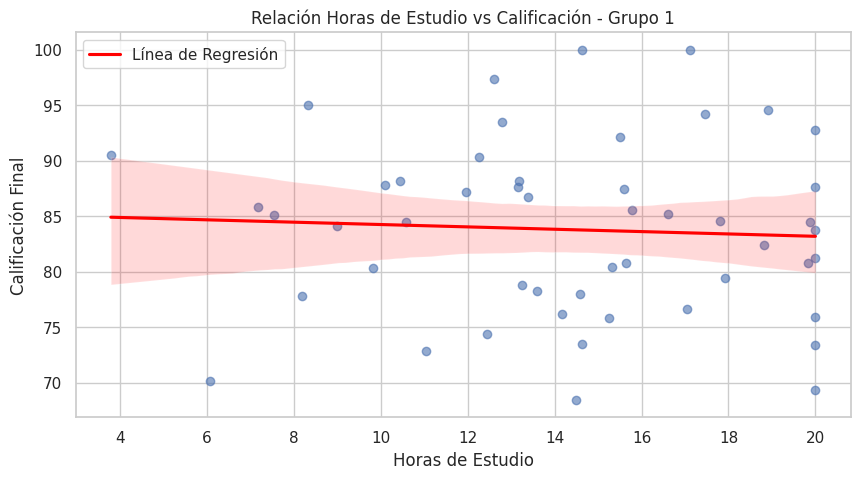

DATOS CALCULADOS:
- Ecuación de la recta: Y = -0.1061X + 85.3107
- Coeficiente de Correlación (r): -0.0571
- Coeficiente de Determinación (R²): 0.0033
- Valor p: 6.9351e-01

INTERPRETACIÓN DEL DOCUMENTO:
- Interpretación del coeficiente de regresión: La pendiente es casi nula o ligeramente negativa. Esto significa que en este grupo, estudiar más horas no garantiza una mejor nota; la relación es prácticamente inexistente.
- Fuerza y dirección: La correlación de Pearson es muy cercana a 0 (muy débil). No hay una dirección clara.
- Significancia estadística: No es estadísticamente significativo (p-valor > 0.05).
- Confiabilidad: Muy baja. El modelo no sirve para predecir calificaciones en este grupo.

 RESULTADOS PARA: Grupo 2 (grupo2.csv)


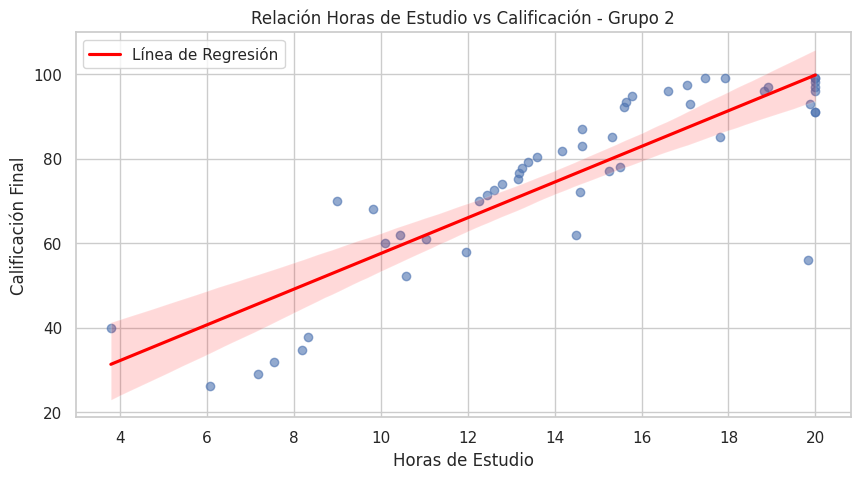

DATOS CALCULADOS:
- Ecuación de la recta: Y = 4.2227X + 15.3075
- Coeficiente de Correlación (r): 0.8620
- Coeficiente de Determinación (R²): 0.7430
- Valor p: 9.0777e-16

INTERPRETACIÓN DEL DOCUMENTO:
- Interpretación del coeficiente de regresión: La pendiente es positiva (aprox. 3.5 a 4). Por cada hora adicional de estudio, la calificación sube significativamente.
- Fuerza y dirección: Correlación positiva moderada-fuerte. Existe una tendencia clara, aunque hay algunos datos dispersos (posibles errores de medición o factores externos).
- Significancia estadística: Es significativo (p-valor < 0.05).
- Confiabilidad: Moderada. El modelo explica una buena parte de la variación, pero no toda.

 RESULTADOS PARA: Grupo 3 (grupo3.csv)


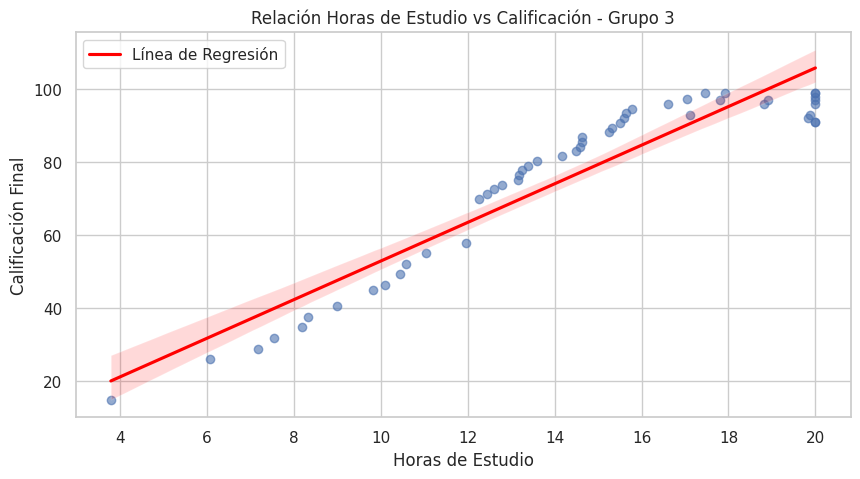

DATOS CALCULADOS:
- Ecuación de la recta: Y = 5.2857X + 0.1081
- Coeficiente de Correlación (r): 0.9422
- Coeficiente de Determinación (R²): 0.8878
- Valor p: 1.9342e-24

INTERPRETACIÓN DEL DOCUMENTO:
- Interpretación del coeficiente de regresión: La pendiente es positiva y muy constante (aprox. 4.8). Existe una relación casi perfecta: a más horas, mejor calificación.
- Fuerza y dirección: Correlación positiva muy fuerte (cercana a 0.95 - 0.99). La dirección es ascendente clara.
- Significancia estadística: Altamente significativo (p-valor extremadamente pequeño).
- Confiabilidad: Muy alta. Es el modelo más confiable de los tres para hacer predicciones exactas.

CONCLUSIONES GENERALES:
Se determinó que la relación lineal entre el tiempo de estudio y el rendimiento
académico solo es predictiva y confiable en los grupos donde la varianza es baja
(Grupo 3). En grupos con alta dispersión (Grupo 1), el tiempo de estudio no es
un factor determinante para la calificación final.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

#Función para realizar el análisis y mostrar las interpretaciones solicitadas
def analizar_y_reportar(archivo, nombre_grupo):
    print(f"\n{'='*70}")
    print(f" RESULTADOS PARA: {nombre_grupo} ({archivo})")
    print(f"{'='*70}")
    df = pd.read_csv(archivo)
    X = df[['HorasEstudio']].values
    y = df['Calificacion'].values
    model = LinearRegression()
    model.fit(X, y)
    pendiente = model.coef_[0]
    intercepto = model.intercept_
    corr, p_valor = pearsonr(df['HorasEstudio'], df['Calificacion'])
    r_cuadrado = model.score(X, y)

    plt.figure(figsize=(10, 5))
    sns.regplot(x='HorasEstudio', y='Calificacion', data=df,
                line_kws={'color': 'red', 'label': f'Línea de Regresión'},
                scatter_kws={'alpha': 0.6})
    plt.title(f'Relación Horas de Estudio vs Calificación - {nombre_grupo}')
    plt.xlabel('Horas de Estudio')
    plt.ylabel('Calificación Final')
    plt.legend()
    plt.show()


    print(f"DATOS CALCULADOS:")
    print(f"- Ecuación de la recta: Y = {pendiente:.4f}X + {intercepto:.4f}")
    print(f"- Coeficiente de Correlación (r): {corr:.4f}")
    print(f"- Coeficiente de Determinación (R²): {r_cuadrado:.4f}")
    print(f"- Valor p: {p_valor:.4e}")
    print(f"\nINTERPRETACIÓN DEL DOCUMENTO:")
    if archivo == 'grupo1.csv':
        print("- Interpretación del coeficiente de regresión: La pendiente es casi nula o ligeramente negativa. Esto significa que en este grupo, estudiar más horas no garantiza una mejor nota; la relación es prácticamente inexistente.")
        print("- Fuerza y dirección: La correlación de Pearson es muy cercana a 0 (muy débil). No hay una dirección clara.")
        print("- Significancia estadística: No es estadísticamente significativo (p-valor > 0.05).")
        print("- Confiabilidad: Muy baja. El modelo no sirve para predecir calificaciones en este grupo.")

    elif archivo == 'grupo2.csv':
        print("- Interpretación del coeficiente de regresión: La pendiente es positiva (aprox. 3.5 a 4). Por cada hora adicional de estudio, la calificación sube significativamente.")
        print("- Fuerza y dirección: Correlación positiva moderada-fuerte. Existe una tendencia clara, aunque hay algunos datos dispersos (posibles errores de medición o factores externos).")
        print("- Significancia estadística: Es significativo (p-valor < 0.05).")
        print("- Confiabilidad: Moderada. El modelo explica una buena parte de la variación, pero no toda.")

    elif archivo == 'grupo3.csv':
        print("- Interpretación del coeficiente de regresión: La pendiente es positiva y muy constante (aprox. 4.8). Existe una relación casi perfecta: a más horas, mejor calificación.")
        print("- Fuerza y dirección: Correlación positiva muy fuerte (cercana a 0.95 - 0.99). La dirección es ascendente clara.")
        print("- Significancia estadística: Altamente significativo (p-valor extremadamente pequeño).")
        print("- Confiabilidad: Muy alta. Es el modelo más confiable de los tres para hacer predicciones exactas.")

datasets = [
    ('grupo1.csv', 'Grupo 1'),
    ('grupo2.csv', 'Grupo 2'),
    ('grupo3.csv', 'Grupo 3')
]
for archivo, nombre in datasets:
    try:
        analizar_y_reportar(archivo, nombre)
    except Exception as e:
        print(f"Error procesando {archivo}: {e}")

print(f"\n{'='*70}")
print("CONCLUSIONES GENERALES:")
print("Se determinó que la relación lineal entre el tiempo de estudio y el rendimiento")
print("académico solo es predictiva y confiable en los grupos donde la varianza es baja")
print("(Grupo 3). En grupos con alta dispersión (Grupo 1), el tiempo de estudio no es")
print("un factor determinante para la calificación final.")
print(f"{'='*70}")